<a href="https://colab.research.google.com/github/TalayPsu/student-dropout-prediction/blob/main/notebooks/01_eda_and_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 2.2.3
scikit-learn: 1.6.1


In [ ]:
!pip install -q imbalanced-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Data Loading

In [ ]:
!pip install -q ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

dataset = fetch_ucirepo(id=697)

X = dataset.data.features
y = dataset.data.targets

df = pd.concat([X, y], axis=1)
print(df.shape)
df.head()

(4424, 37)


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [ ]:
# ขนาดและชนิดข้อมูล
print(df.shape)
df.info()

# ตรวจค่าที่ขาดหาย
print(df.isnull().sum().sum(), "missing values")

# สัดส่วน label
print(df['Target'].value_counts())
print(df['Target'].value_counts(normalize=True).round(3))

(4424, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification        

In [ ]:
import os
os.makedirs('/content/drive/MyDrive/dropout-project', exist_ok=True)
df.to_csv('/content/drive/MyDrive/dropout-project/raw_dropout.csv', index=False)

# 3. Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# สร้างคอลัมน์ label แบบ binary (แนวทาง A) ไว้ใช้ดูกราฟ
df['Dropout'] = (df['Target'] == 'Dropout').astype(int)
print(df['Dropout'].value_counts(normalize=True).round(3))

Dropout
0    0.679
1    0.321
Name: proportion, dtype: float64


In [ ]:
# ซ้ำกับเดิม แต่ใส่ไว้ให้ notebook ครบถ้วน
print("Missing values:", df.isnull().sum().sum())

# ตรวจแถวซ้ำ
print("Duplicate rows:", df.duplicated().sum())

# สถิติพื้นฐานของฟีเจอร์ตัวเลขจริง
num_cols = [
    'Previous qualification (grade)', 'Admission grade', 'Age at enrollment',
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Unemployment rate', 'Inflation rate', 'GDP'
]
df[num_cols].describe().round(2)

Missing values: 0
Duplicate rows: 0


,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,132.61,126.98,23.27,10.64,10.23,11.57,1.23,0.00
std,13.19,14.48,7.59,4.84,5.21,2.66,1.38,2.27
min,95.00,95.00,17.00,0.00,0.00,7.60,-0.80,-4.06
25%,125.00,117.90,19.00,11.00,10.75,9.40,0.30,-1.70
50%,133.10,126.10,20.00,12.29,12.20,11.10,1.40,0.32
75%,140.00,134.80,25.00,13.40,13.33,13.90,2.60,1.79
max,190.00,190.00,70.00,18.88,18.57,16.20,3.70,3.51


## 3.1 ตรวจ missing values และ outliers

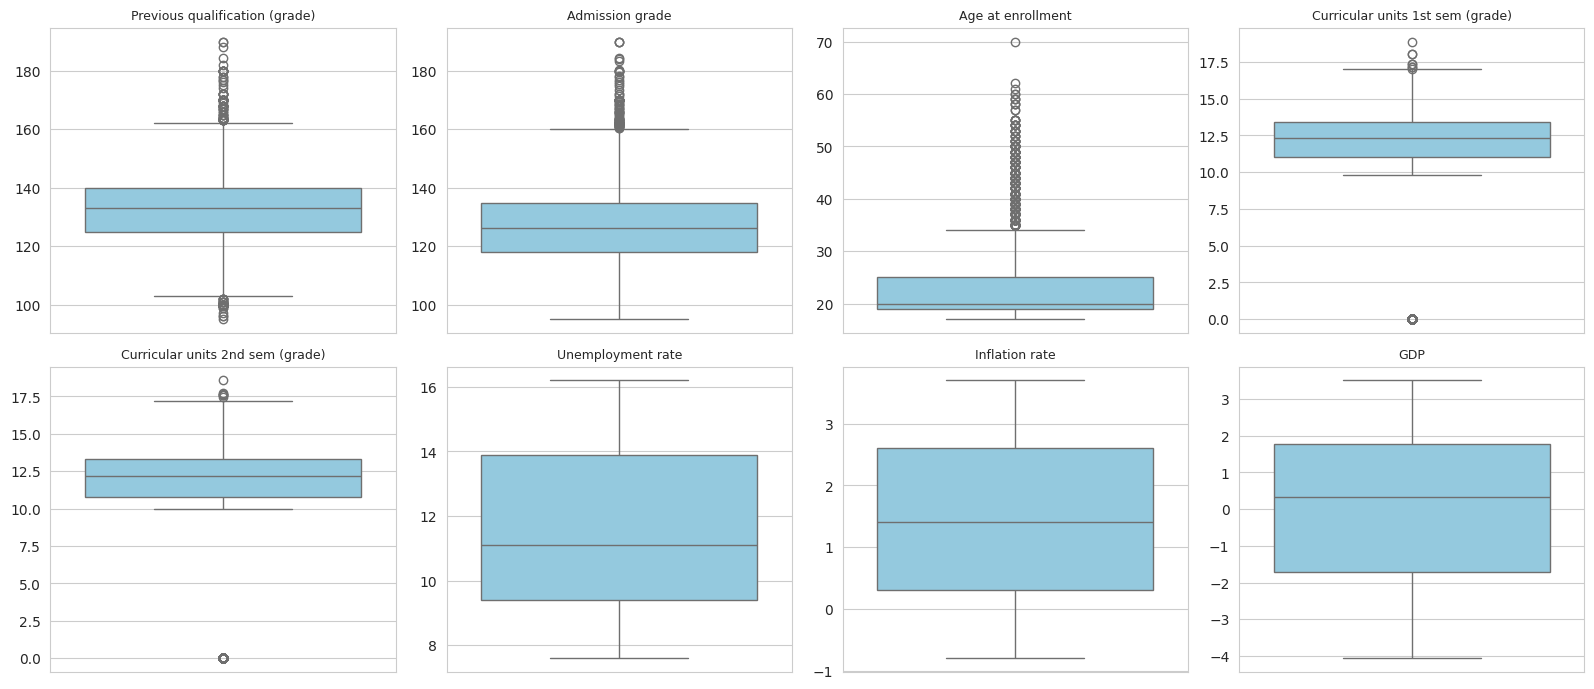

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=df[col], ax=ax, color='skyblue')
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

**สรุป 3.1: ตรวจสอบ Missing Values และ Outliers**

- ชุดข้อมูลมี 4,424 แถว ไม่พบ missing values (0 ค่า) และไม่พบแถวซ้ำ (0 ค่า)
- **พบ outliers ในหลายฟีเจอร์:**
  - `Age at enrollment`: ค่ากลางอยู่ที่ประมาณ 20 ปี แต่มี outliers จำนวนมากในช่วง 35-70 ปี สะท้อนว่ามีนักศึกษาผู้ใหญ่ที่เข้าเรียนในวัยที่สูงกว่าปกติ
  - `Previous qualification (grade)` และ `Admission grade`: มี outliers ด้านคะแนนสูง (ประมาณ 160-190) และ `Previous qualification (grade)` มี outliers ด้านคะแนนต่ำ (ประมาณ 95-102) ด้วย
  - `Curricular units 1st/2nd sem (grade)`: มี outliers ที่ค่า 0 และค่าสูงใกล้ 17-19
  - `Unemployment rate`, `Inflation rate`, `GDP`: ไม่พบ outliers
- **การตัดสินใจ:** ไม่ลบ outliers ออก เพราะ (1) ค่าเหล่านี้เป็นข้อมูลที่เกิดขึ้นจริง เช่น นักศึกษาผู้ใหญ่ (2) เกรดที่เป็น 0 อาจหมายถึงนักศึกษาที่ไม่ได้เข้ารับการประเมิน ซึ่งอาจเป็นสัญญาณสำคัญของความเสี่ยงลาออก การลบทิ้งจะทำให้โมเดลสูญเสียข้อมูลที่มีประโยชน์ และ (3) แหล่งข้อมูล UCI ระบุว่าข้อมูลผ่านการทำความสะอาดมาแล้ว
- โมเดลที่ใช้ Random Forest ไม่อ่อนไหวต่อ outliers มากนัก ส่วน Logistic Regression และ SVM จะใช้ StandardScaler ช่วยปรับสเกลก่อนฝึก

## 3.2 สัดส่วน Target

/tmp/ipykernel_721/2265199030.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Target', order=order, ax=axes[0], palette='Set2')
/tmp/ipykernel_721/2265199030.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Dropout', ax=axes[1], palette=['#4CAF82', '#E3522B'])
/tmp/ipykernel_721/2265199030.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Dropout (0)', 'Dropout (1)'])


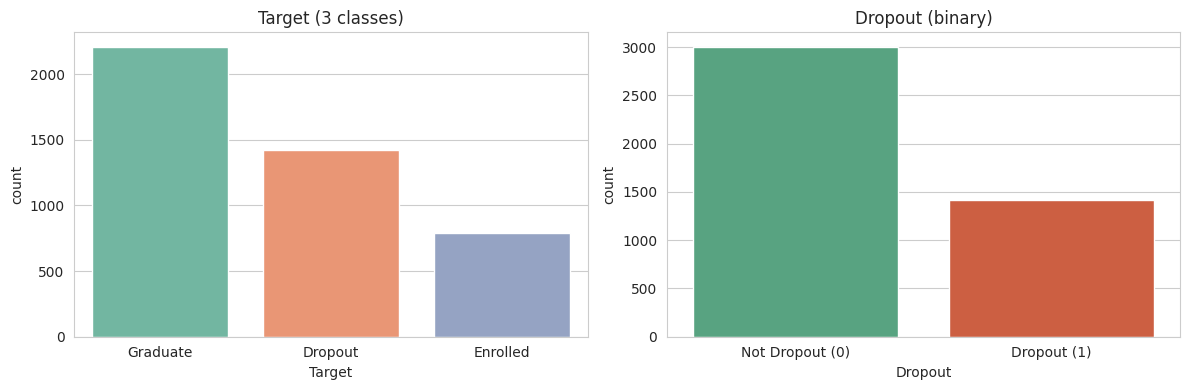

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3 คลาสเดิม
order = ['Graduate', 'Dropout', 'Enrolled']
sns.countplot(data=df, x='Target', order=order, ax=axes[0], palette='Set2')
axes[0].set_title('Target (3 classes)')

# Binary
sns.countplot(data=df, x='Dropout', ax=axes[1], palette=['#4CAF82', '#E3522B'])
axes[1].set_xticklabels(['Not Dropout (0)', 'Dropout (1)'])
axes[1].set_title('Dropout (binary)')

plt.tight_layout()
plt.show()

**สรุป 3.2: การกระจายตัวของ Target**

- Target เดิมมี 3 คลาส: Graduate 2,209 คน (49.9%), Dropout 1,421 คน (32.1%) และ Enrolled 794 คน (17.9%)
- เพื่อให้สอดคล้องกับวัตถุประสงค์ของโครงงาน (พยากรณ์ความเสี่ยงลาออก) จึงแปลงเป็น binary โดยกำหนด Dropout = 1 และ Graduate/Enrolled = 0 ได้ Not Dropout ประมาณ 3,000 คน (67.9%) และ Dropout 1,421 คน (32.1%)
- ข้อมูลมีความไม่สมดุลระดับปานกลาง (กลุ่ม Dropout น้อยกว่าประมาณครึ่งหนึ่งของกลุ่ม Not Dropout) ไม่รุนแรงมาก จึงวางแผนใช้ SMOTE กับชุด train เท่านั้น และเปรียบเทียบผลระหว่างกรณีมีและไม่มี SMOTE
- เนื่องจากคลาสไม่สมดุล การประเมินโมเดลจะไม่ใช้ Accuracy เพียงอย่างเดียว แต่ให้ความสำคัญกับ Recall, Precision และ F1-score ของกลุ่ม Dropout

## 3.3 ความสัมพันธ์ระหว่างฟีเจอร์กับการลาออก

(ก) ฟีเจอร์ผลการเรียน เทียบ Dropout vs ไม่ Dropout

/tmp/ipykernel_721/4085557358.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Dropout', y=col, ax=ax, palette=['#4CAF82', '#E3522B'])
/tmp/ipykernel_721/4085557358.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Dropout', 'Dropout'])
/tmp/ipykernel_721/4085557358.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Dropout', y=col, ax=ax, palette=['#4CAF82', '#E3522B'])
/tmp/ipykernel_721/4085557358.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabel

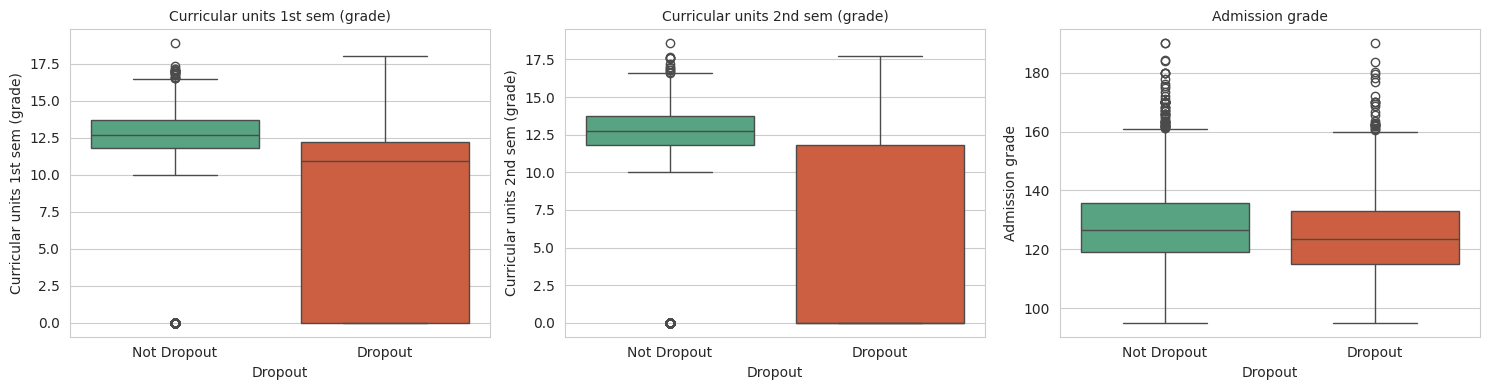

In [ ]:
grade_cols = [
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Admission grade'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, grade_cols):
    sns.boxplot(data=df, x='Dropout', y=col, ax=ax, palette=['#4CAF82', '#E3522B'])
    ax.set_xticklabels(['Not Dropout', 'Dropout'])
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

**สรุป 3.3(ก): ผลการเรียนกับการลาออก**

- **เกรดภาคเรียนที่ 1 และ 2:** นักศึกษาที่ไม่ลาออกมีเกรดค่อนข้างสูงและกระจุกตัว (ค่ากลางประมาณ 12.5-13 โดยกล่องอยู่ราว 12-14) ขณะที่กลุ่มที่ลาออกมีค่ากลางต่ำกว่าอย่างชัดเจน และกล่องกระจายกว้างมากตั้งแต่ 0 ถึงประมาณ 12 แสดงว่ามีนักศึกษาที่ลาออกจำนวนมากได้เกรดเป็น 0
- ค่าเกรด 0 ในกลุ่มที่ลาออกน่าจะหมายถึงนักศึกษาที่ไม่ได้เข้ารับการประเมินในภาคเรียนนั้น จึงเป็นสัญญาณเตือนที่สำคัญ
- **Admission grade (เกรดตอนเข้า):** ทั้งสองกลุ่มมีค่ากลางใกล้เคียงกัน (กลุ่มไม่ลาออกประมาณ 127 กลุ่มลาออกประมาณ 124) และการกระจายซ้อนทับกันมาก แสดงว่าเกรดตอนเข้าแยกสองกลุ่มได้ไม่ชัดเจน
- **ข้อสรุป:** ผลการเรียนหลังเข้าศึกษาแล้วบอกความเสี่ยงได้ดีกว่าคะแนนตอนเข้า สอดคล้องกับข้อเสนอโครงงานที่คาดว่าเกรดเป็นปัจจัยสำคัญ

(ข) ฟีเจอร์ทางการเงิน/สถานะ (ฟีเจอร์ 0/1) ดูอัตราการลาออกในแต่ละกลุ่ม

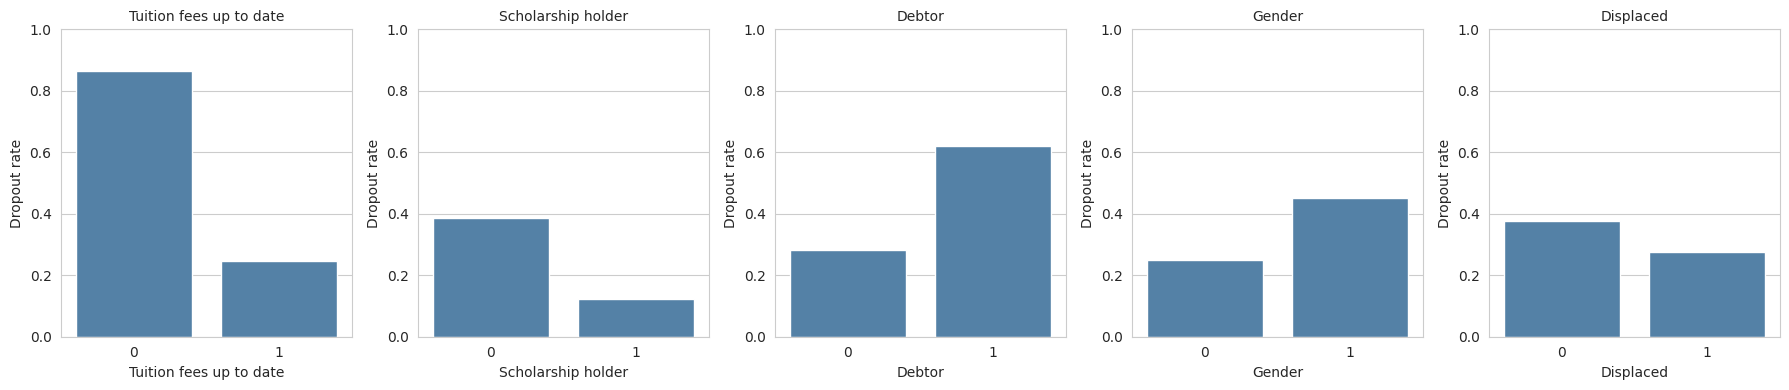

In [ ]:
bin_cols = ['Tuition fees up to date', 'Scholarship holder', 'Debtor', 'Gender', 'Displaced']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, bin_cols):
    rate = df.groupby(col)['Dropout'].mean()
    sns.barplot(x=rate.index, y=rate.values, ax=ax, color='steelblue')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Dropout rate')
    ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

**สรุป 3.3(ข): สถานะทางการเงิน/ส่วนบุคคลกับอัตราการลาออก**

- **Tuition fees up to date:** กลุ่มที่ค่าเทอมไม่เป็นปัจจุบัน (0) มีอัตราลาออกประมาณ 86% เทียบกับประมาณ 24% ในกลุ่มที่ชำระเป็นปัจจุบัน (1) ซึ่งเป็นความแตกต่างที่มากที่สุดในกลุ่มนี้
- **Scholarship holder:** ผู้ที่ได้รับทุน (1) มีอัตราลาออกประมาณ 12% เทียบกับประมาณ 38% ในกลุ่มที่ไม่ได้รับทุน (0)
- **Debtor:** กลุ่มที่มีหนี้ (1) มีอัตราลาออกประมาณ 62% เทียบกับประมาณ 28% ในกลุ่มไม่มีหนี้ (0)
- **Gender:** กลุ่มรหัส 1 มีอัตราลาออกประมาณ 45% เทียบกับประมาณ 25% ในกลุ่มรหัส 0 (ตามคำอธิบายชุดข้อมูล 1 = ชาย, 0 = หญิง)
- **Displaced:** ความแตกต่างค่อนข้างน้อย (กลุ่ม 0 ประมาณ 37% กลุ่ม 1 ประมาณ 27%)
- ผลชี้ว่าปัจจัยด้านการเงินมีความเกี่ยวข้องกับการลาออกอย่างชัดเจน ซึ่งสนับสนุนแนวคิดของโครงงานที่ให้โรงเรียนจัดสรรทุนการศึกษาแก่กลุ่มเสี่ยง
- **หมายเหตุ:** ผลนี้แสดงความสัมพันธ์ (correlation) ไม่ใช่ความเป็นเหตุเป็นผล (causation)

(ค) Correlation กับ Dropout

Curricular units 2nd sem (grade)      -0.572
Curricular units 2nd sem (approved)   -0.570
Curricular units 1st sem (grade)      -0.481
Curricular units 1st sem (approved)   -0.479
Tuition fees up to date               -0.429
Age at enrollment                      0.254
Scholarship holder                    -0.245
Debtor                                 0.229
Gender                                 0.204
Application mode                       0.198
Name: Dropout, dtype: float64


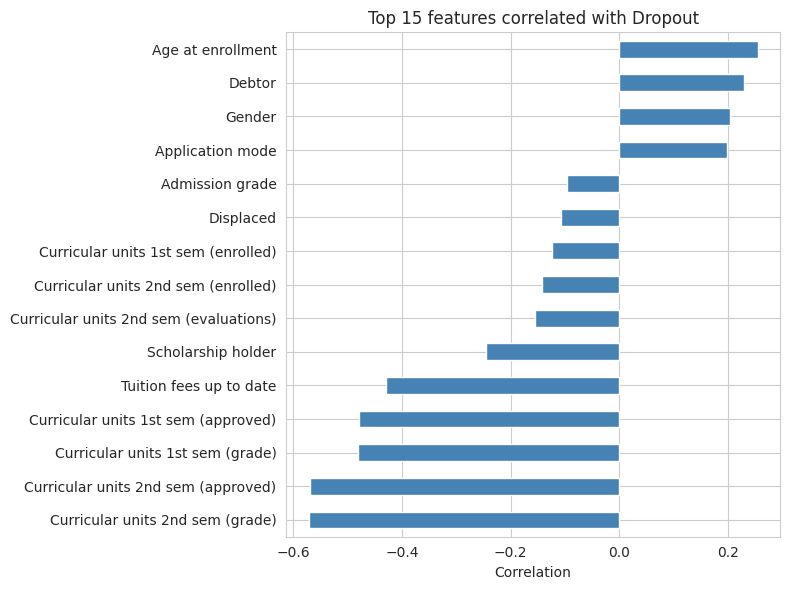

In [ ]:
# ใช้เฉพาะคอลัมน์ตัวเลข
corr = df.drop(columns=['Target']).corr()['Dropout'].drop('Dropout')
corr_sorted = corr.reindex(corr.abs().sort_values(ascending=False).index)

print(corr_sorted.head(10).round(3))

plt.figure(figsize=(8, 6))
corr_sorted.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 features correlated with Dropout')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

**สรุป 3.3(ค): ฟีเจอร์ที่สัมพันธ์กับการลาออกมากที่สุด**

- **ฟีเจอร์ที่สัมพันธ์เชิงลบสูงสุด (ค่ามาก → ลาออกน้อยลง):** `Curricular units 2nd sem (grade)` (r = -0.572), `Curricular units 2nd sem (approved)` (r = -0.570), `Curricular units 1st sem (grade)` (r = -0.481), `Curricular units 1st sem (approved)` (r = -0.479) และ `Tuition fees up to date` (r = -0.429)
- **ฟีเจอร์ที่สัมพันธ์เชิงบวก (ค่ามาก → ลาออกมากขึ้น):** `Age at enrollment` (r = 0.254), `Debtor` (r = 0.229), `Gender` (r = 0.204)
- `Scholarship holder` (r = -0.245) สัมพันธ์เชิงลบ สอดคล้องกับกราฟ 3.3(ข) ที่ผู้ได้รับทุนลาออกน้อยกว่า
- ฟีเจอร์ด้านผลการเรียนและจำนวนวิชาที่ผ่านในภาคเรียนที่ 1-2 มีความสัมพันธ์สูงที่สุด ส่วนตัวแปรเศรษฐกิจมหภาค (`Unemployment rate`, `Inflation rate`, `GDP`) ไม่ปรากฏใน 15 อันดับแรก แสดงว่าสัมพันธ์กับการลาออกต่ำ
- **ข้อจำกัด:** correlation แบบ Pearson ให้ความหมายได้เฉพาะฟีเจอร์ตัวเลขจริงและฟีเจอร์ 0/1 ส่วน `Application mode` ที่ปรากฏในลำดับเป็นรหัสหมวดหมู่ ค่า correlation จึงไม่มีความหมายเชิงทิศทาง ฟีเจอร์ประเภทนี้จะประเมินความสำคัญอีกครั้งด้วย Feature Importance ของ Random Forest หลังทำ One-Hot Encoding

# 4. Data Preprocessing

## 4.1 กำหนด Label และกลุ่มฟีเจอร์



In [ ]:
# ตั้งค่าเสริม: False = ใช้ฟีเจอร์ครบ, True = ตัดฟีเจอร์ภาคเรียนที่ 2 (เตือนล่วงหน้าตั้งแต่ภาคแรก)
EARLY_WARNING = False

y = df['Dropout']

# สำคัญ: ต้องตัดทั้ง Target และ Dropout ออกจาก X ไม่เช่นนั้นโมเดลจะเห็นคำตอบ
X = df.drop(columns=['Target', 'Dropout'])

if EARLY_WARNING:
    X = X.drop(columns=[c for c in X.columns if '2nd sem' in c])

# แบ่งกลุ่มฟีเจอร์ตามชนิด
cat_cols = [
    'Marital Status', 'Application mode', 'Course', 'Previous qualification',
    'Nacionality', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation"
]
bin_cols = [
    'Daytime/evening attendance', 'Displaced', 'Educational special needs',
    'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International'
]
num_cols = [c for c in X.columns if c not in cat_cols + bin_cols]

print("หมวดหมู่ (One-Hot):", len(cat_cols))
print("0/1 (ไม่ต้องแปลง):", len(bin_cols))
print("ตัวเลขจริง (Scale):", len(num_cols))
print(num_cols)

หมวดหมู่ (One-Hot): 9
0/1 (ไม่ต้องแปลง): 8
ตัวเลขจริง (Scale): 19
['Application order', 'Previous qualification (grade)', 'Admission grade', 'Age at enrollment', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']


## 4.2 แบ่งข้อมูล Train / Validation / Test (70/15/15)


In [ ]:
from sklearn.model_selection import train_test_split

# ขั้นแรก: 70% train, 30% เก็บไว้แบ่งต่อ
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# ขั้นสอง: แบ่ง 30% ครึ่งๆ เป็น validation 15% และ test 15%
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
for name, yy in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(name, "dropout ratio:", round(yy.mean(), 3))

Train: (3096, 36) | Val: (664, 36) | Test: (664, 36)
Train dropout ratio: 0.321
Val dropout ratio: 0.322
Test dropout ratio: 0.321


## 4.3 Encoding และ Scaling (fit บน train เท่านั้น)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ('bin', 'passthrough', bin_cols),
    ]
)

# fit เฉพาะ train แล้ว transform ทั้ง 3 ชุด
X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
print("Train:", X_train_p.shape, "| Val:", X_val_p.shape, "| Test:", X_test_p.shape)
print("จำนวนฟีเจอร์หลัง Encoding:", len(feature_names))

Train: (3096, 230) | Val: (664, 230) | Test: (664, 230)
จำนวนฟีเจอร์หลัง Encoding: 230


In [ ]:
import numpy as np

print("มี NaN ไหม:", np.isnan(X_train_p).any())

# ฟีเจอร์ตัวเลขใน train หลัง Scale ควรมี mean ≈ 0, std ≈ 1
n = len(num_cols)
print("mean:", X_train_p[:, :n].mean().round(3), "| std:", X_train_p[:, :n].std().round(3))

มี NaN ไหม: False
mean: 0.0 | std: 1.0


## 4.4 จัดการความไม่สมดุลด้วย SMOTE (เฉพาะ train)

In [ ]:
from imblearn.over_sampling import SMOTE

print("ก่อน SMOTE:\n", y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_p, y_train)

print("\nหลัง SMOTE:\n", y_train_sm.value_counts())
print("ขนาด:", X_train_sm.shape)

ก่อน SMOTE:
 Dropout
0    2102
1     994
Name: count, dtype: int64

หลัง SMOTE:
 Dropout
0    2102
1    2102
Name: count, dtype: int64
ขนาด: (4204, 230)


## 4.5 บันทึก preprocessor

In [ ]:
import joblib

joblib.dump(preprocessor, '/content/drive/MyDrive/dropout-project/preprocessor.joblib')
print("saved")

saved


**สรุปขั้นตอน Preprocessing**

- กำหนด label แบบ binary (Dropout = 1, อื่นๆ = 0) และตัดคอลัมน์ `Target` กับ `Dropout` ออกจากฟีเจอร์เพื่อป้องกันการรั่วของคำตอบ
- แบ่งข้อมูลเป็น Train / Validation / Test ในสัดส่วน 70 / 15 / 15 แบบ stratified เพื่อให้สัดส่วน Dropout ในทุกชุดใกล้เคียงกัน (ประมาณ 32%)
- ฟีเจอร์ที่เป็นรหัสหมวดหมู่ (เช่น `Course`, `Application mode`, อาชีพและวุฒิการศึกษาผู้ปกครอง) แปลงด้วย One-Hot Encoding ฟีเจอร์ตัวเลขจริงปรับสเกลด้วย StandardScaler และฟีเจอร์ 0/1 คงไว้ตามเดิม
- การ fit ตัว Encoder และ Scaler ทำบนชุด train เท่านั้น แล้วนำไป transform ชุด validation และ test เพื่อป้องกัน data leakage
- ใช้ SMOTE กับชุด train เท่านั้น เพื่อปรับสัดส่วนคลาสให้สมดุล โดยเก็บข้อมูลทั้งแบบมีและไม่มี SMOTE ไว้เปรียบเทียบผลในขั้นสร้างโมเดล
- **ข้อจำกัด:** SMOTE ทำให้ค่าในคอลัมน์ One-Hot เป็นทศนิยม และไม่ได้ลบ outliers เนื่องจากเป็นข้อมูลจริงที่มีความหมาย

# 5. Model Training

## 5.1 ฟังก์ชันประเมินผล

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

def evaluate(model, X, y):
    """คืนค่าเมตริกของคลาส Dropout (label = 1)"""
    pred = model.predict(X)
    if hasattr(model, 'predict_proba'):
        score = model.predict_proba(X)[:, 1]
    else:
        score = model.decision_function(X)
    return {
        'Accuracy':  accuracy_score(y, pred),
        'Precision': precision_score(y, pred),
        'Recall':    recall_score(y, pred),
        'F1':        f1_score(y, pred),
        'ROC-AUC':   roc_auc_score(y, score),
    }

# ชุดข้อมูลสองเวอร์ชันที่จะเปรียบเทียบ
datasets = {
    'No SMOTE': (X_train_p,  y_train),
    'SMOTE':    (X_train_sm, y_train_sm),
}

## 5.2 Baseline: ฝึก 3 โมเดลด้วยค่าเริ่มต้น (มี/ไม่มี SMOTE)

In [ ]:
base_models = {
    'Logistic Regression': lambda: LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       lambda: RandomForestClassifier(random_state=42, n_jobs=-1),
    'SVM':                 lambda: SVC(random_state=42),
}

rows = []
for dname, (Xtr, ytr) in datasets.items():
    for mname, make in base_models.items():
        t0 = time.time()
        model = make().fit(Xtr, ytr)
        res = evaluate(model, X_val_p, y_val)
        rows.append({'Data': dname, 'Model': mname, **res,
                     'Train time (s)': time.time() - t0})

baseline = pd.DataFrame(rows).round(3)
baseline

,Data,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train time (s)
0,No SMOTE,Logistic Regression,0.873,0.849,0.738,0.790,0.925,2.099
1,No SMOTE,Random Forest,0.867,0.884,0.678,0.767,0.927,2.082
2,No SMOTE,SVM,0.875,0.897,0.692,0.781,0.929,3.236
3,SMOTE,Logistic Regression,0.866,0.764,0.846,0.803,0.926,1.127
4,SMOTE,Random Forest,0.877,0.851,0.748,0.796,0.922,1.729
5,SMOTE,SVM,0.875,0.802,0.813,0.807,0.933,2.806


## 5.3 Hyperparameter Tuning บน Validation Set

In [ ]:
grids = {
    'Logistic Regression': (
        lambda **p: LogisticRegression(max_iter=2000, random_state=42, **p),
        {'C': [0.01, 0.1, 1, 10]}),
    'Random Forest': (
        lambda **p: RandomForestClassifier(random_state=42, n_jobs=-1, **p),
        {'n_estimators': [200, 400], 'max_depth': [None, 10, 20],
         'min_samples_leaf': [1, 3]}),
    'SVM': (
        lambda **p: SVC(random_state=42, **p),
        {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01]}),
}

tuned_models = {}   # เก็บโมเดลที่ดีที่สุดของแต่ละคู่ (ชุดข้อมูล, โมเดล)
rows = []

for dname, (Xtr, ytr) in datasets.items():
    for mname, (make, grid) in grids.items():
        best_f1, best_params, best_model = -1, None, None
        for params in ParameterGrid(grid):
            m = make(**params).fit(Xtr, ytr)
            f1 = f1_score(y_val, m.predict(X_val_p))
            if f1 > best_f1:
                best_f1, best_params, best_model = f1, params, m

        tuned_models[(dname, mname)] = best_model
        res = evaluate(best_model, X_val_p, y_val)
        train_f1 = f1_score(y_train, best_model.predict(X_train_p))  # วัดบน train จริง (ไม่ใช่ SMOTE)
        rows.append({'Data': dname, 'Model': mname, **res,
                     'Train F1': train_f1, 'Best params': best_params})
        print(f"done: {dname} / {mname} -> {best_params}")

tuned = pd.DataFrame(rows)
tuned_show = tuned.drop(columns='Best params').round(3)
tuned_show

done: No SMOTE / Logistic Regression -> {'C': 1}
done: No SMOTE / Random Forest -> {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 400}
done: No SMOTE / SVM -> {'C': 1, 'gamma': 'scale'}
done: SMOTE / Logistic Regression -> {'C': 0.1}
done: SMOTE / Random Forest -> {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 400}
done: SMOTE / SVM -> {'C': 1, 'gamma': 0.01}


,Data,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train F1
0,No SMOTE,Logistic Regression,0.873,0.849,0.738,0.790,0.925,0.820
1,No SMOTE,Random Forest,0.872,0.886,0.692,0.777,0.928,0.986
2,No SMOTE,SVM,0.875,0.897,0.692,0.781,0.929,0.832
3,SMOTE,Logistic Regression,0.873,0.773,0.860,0.814,0.930,0.808
4,SMOTE,Random Forest,0.880,0.835,0.780,0.807,0.925,0.885
5,SMOTE,SVM,0.881,0.795,0.850,0.822,0.933,0.815


In [ ]:
tuned[['Data', 'Model', 'F1', 'Best params']].round(3)

,Data,Model,F1,Best params
0,No SMOTE,Logistic Regression,0.790,{'C': 1}
1,No SMOTE,Random Forest,0.777,"{'max_depth': 20, 'min_samples_leaf': 1, 'n_es..."
2,No SMOTE,SVM,0.781,"{'C': 1, 'gamma': 'scale'}"
3,SMOTE,Logistic Regression,0.814,{'C': 0.1}
4,SMOTE,Random Forest,0.807,"{'max_depth': 10, 'min_samples_leaf': 1, 'n_es..."
5,SMOTE,SVM,0.822,"{'C': 1, 'gamma': 0.01}"


## 5.4 บันทึกโมเดล

In [ ]:
import joblib
joblib.dump(tuned_models, '/content/drive/MyDrive/dropout-project/tuned_models.joblib')
baseline.to_csv('/content/drive/MyDrive/dropout-project/baseline_val.csv', index=False)
tuned_show.to_csv('/content/drive/MyDrive/dropout-project/tuned_val.csv', index=False)

## สรุปการฝึกและปรับจูนโมเดล

ฝึกโมเดล 3 แบบ ได้แก่ Logistic Regression, Random Forest และ SVM โดยทดลองทั้งแบบ **ไม่ใช้ SMOTE** และ **ใช้ SMOTE** กับชุด train จากนั้นปรับจูน hyperparameter ด้วย grid search และเลือกค่าที่ให้ F1-score ของกลุ่ม Dropout สูงสุดบนชุด Validation (ยังไม่ใช้ชุด Test เพื่อป้องกันการเลือกโมเดลจากข้อมูลทดสอบ)

### ผลหลังปรับจูน (ประเมินบน Validation set, เมตริกของกลุ่ม Dropout)

| Data | Model | Accuracy | Precision | Recall | F1 | ROC-AUC | Train F1 |
|---|---|---|---|---|---|---|---|
| No SMOTE | Logistic Regression | 0.873 | 0.849 | 0.738 | 0.790 | 0.925 | 0.820 |
| No SMOTE | Random Forest | 0.872 | 0.886 | 0.692 | 0.777 | 0.928 | 0.986 |
| No SMOTE | SVM | 0.875 | 0.897 | 0.692 | 0.781 | 0.929 | 0.832 |
| SMOTE | Logistic Regression | 0.873 | 0.773 | 0.860 | 0.814 | 0.930 | 0.808 |
| SMOTE | Random Forest | 0.880 | 0.835 | 0.780 | 0.807 | 0.925 | 0.885 |
| SMOTE | SVM | 0.881 | 0.795 | 0.850 | **0.822** | 0.933 | 0.815 |

(Train F1 วัดบนชุด train ต้นฉบับที่ไม่ผ่าน SMOTE)

### ข้อสังเกต

**1. โมเดลที่ดีที่สุดบน Validation**
SVM ที่ใช้ SMOTE (C = 1, gamma = 0.01) ให้ F1 สูงสุด = 0.822 โดยมี Recall = 0.850, Precision = 0.795, Accuracy = 0.881 และ ROC-AUC = 0.933 ซึ่งสูงสุดในทุกเมตริกยกเว้น Precision ที่ต่ำกว่าโมเดลแบบไม่ใช้ SMOTE

**2. ผลของ SMOTE**
SMOTE ช่วยเพิ่ม **Recall ของกลุ่ม Dropout** อย่างชัดเจนในทั้ง 3 โมเดล (หลังจูน): Logistic Regression จาก 0.738 เป็น 0.860 (+0.122), Random Forest จาก 0.692 เป็น 0.780 (+0.088) และ SVM จาก 0.692 เป็น 0.850 (+0.158) แลกกับ Precision ที่ลดลง (Logistic Regression 0.849 → 0.773, Random Forest 0.886 → 0.835, SVM 0.897 → 0.795) F1 โดยรวมดีขึ้นในทุกโมเดล (+0.024 ถึง +0.041) สำหรับโจทย์นี้ซึ่งการพลาดนักเรียนเสี่ยงสูงเสียหายกว่าการเตือนเกิน การเพิ่ม Recall จึงเป็นข้อดี

**3. การตรวจ Overfitting**
Random Forest แบบไม่ใช้ SMOTE มี Train F1 = 0.986 แต่ Validation F1 = 0.777 (ต่างกันประมาณ 0.21) แสดงว่า Overfit ชัดเจน ส่วน Random Forest แบบ SMOTE ที่จำกัด max_depth = 10 ช่องว่างลดเหลือประมาณ 0.08 (Train 0.885 เทียบกับ Val 0.807) Logistic Regression และ SVM มี Train F1 ใกล้เคียง Validation F1 (ต่างกันไม่เกินประมาณ 0.05) จึงไม่พบ Overfitting ที่น่ากังวล

**4. ความแตกต่างระหว่างโมเดลมีไม่มาก**
F1 ของทุกโมเดลอยู่ในช่วง 0.777-0.822 และ ROC-AUC อยู่ในช่วง 0.925-0.933 เท่านั้น เมื่อดูเฉพาะแบบที่ใช้ SMOTE, SVM (0.822), Logistic Regression (0.814) และ Random Forest (0.807) ต่างกันไม่ถึง 0.02 ซึ่ง Validation set ขนาด 664 คน (Dropout ประมาณ 214 คน) อาจทำให้ความต่างระดับนี้อยู่ในช่วงความคลาดเคลื่อนได้ จึงควรตีความว่าทั้ง 3 โมเดลทำได้ใกล้เคียงกัน ไม่ใช่ว่าโมเดลใดดีกว่าอย่างเด็ดขาด

**5. ความสามารถในการตีความ**
เนื่องจาก Logistic Regression ให้ผลใกล้เคียง SVM มากและตีความค่าน้ำหนักได้ง่ายกว่า จึงเป็นทางเลือกที่น่าสนใจหากต้องการสมดุลระหว่างความแม่นยำกับความสามารถในการอธิบายผลต่อครู ส่วน Random Forest มีข้อดีด้าน Feature Importance ที่ใช้อธิบายปัจจัยเสี่ยงในแดชบอร์ด

### ข้อสรุปและขั้นตอนต่อไป
เลือก **SVM + SMOTE** เป็นโมเดลหลักตามเกณฑ์ F1 บน Validation และจะนำโมเดลนี้ไปประเมินบนชุด Test เพียงครั้งเดียวในขั้นถัดไป พร้อมแสดง Confusion Matrix เปรียบเทียบกับ Logistic Regression และ Random Forest เพื่อยืนยันผล

# 6. Model Evaluation

## 6.1 ตารางเปรียบเทียบบน Test set

In [ ]:
rows = []
for (dname, mname), model in tuned_models.items():
    res = evaluate(model, X_test_p, y_test)
    rows.append({'Data': dname, 'Model': mname, **res})

test_results = pd.DataFrame(rows).round(3)
test_results

,Data,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,No SMOTE,Logistic Regression,0.902,0.889,0.793,0.839,0.943
1,No SMOTE,Random Forest,0.878,0.863,0.737,0.795,0.935
2,No SMOTE,SVM,0.887,0.888,0.742,0.808,0.935
3,SMOTE,Logistic Regression,0.877,0.784,0.850,0.815,0.941
4,SMOTE,Random Forest,0.873,0.812,0.789,0.800,0.928
5,SMOTE,SVM,0.890,0.810,0.859,0.834,0.938


In [ ]:
final_key = ('SMOTE', 'SVM')
final_model = tuned_models[final_key]

val_res  = evaluate(final_model, X_val_p,  y_val)
test_res = evaluate(final_model, X_test_p, y_test)

compare = pd.DataFrame({'Validation': val_res, 'Test': test_res}).round(3)
compare['Diff (Test - Val)'] = (compare['Test'] - compare['Validation']).round(3)
compare

,Validation,Test,Diff (Test - Val)
Accuracy,0.881,0.890,0.009
Precision,0.795,0.810,0.015
Recall,0.850,0.859,0.009
F1,0.822,0.834,0.012
ROC-AUC,0.933,0.938,0.005


## 6.2 Confusion Matrix

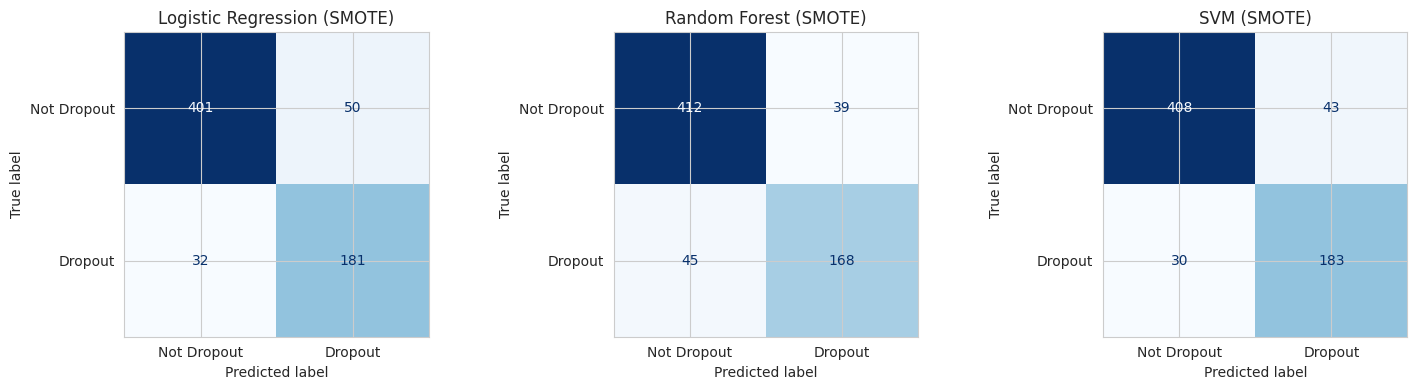

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

smote_models = ['Logistic Regression', 'Random Forest', 'SVM']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, mname in zip(axes, smote_models):
    model = tuned_models[('SMOTE', mname)]
    ConfusionMatrixDisplay.from_estimator(
        model, X_test_p, y_test,
        display_labels=['Not Dropout', 'Dropout'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(f'{mname} (SMOTE)')
plt.tight_layout()
plt.show()

## 6.3 Classification Report และ ROC Curve ของโมเดลหลัก

              precision    recall  f1-score   support

 Not Dropout      0.932     0.905     0.918       451
     Dropout      0.810     0.859     0.834       213

    accuracy                          0.890       664
   macro avg      0.871     0.882     0.876       664
weighted avg      0.892     0.890     0.891       664



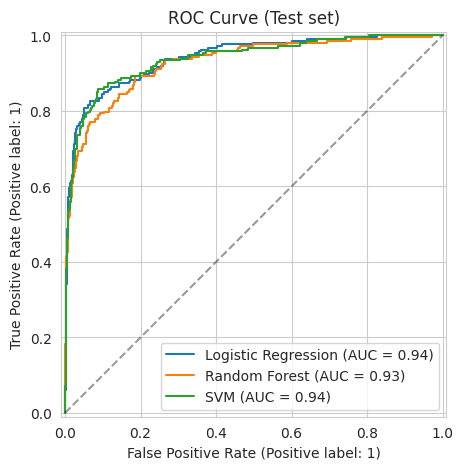

In [ ]:
from sklearn.metrics import classification_report, RocCurveDisplay

y_pred = final_model.predict(X_test_p)
print(classification_report(y_test, y_pred,
                            target_names=['Not Dropout', 'Dropout'], digits=3))

fig, ax = plt.subplots(figsize=(5, 5))
for mname in smote_models:
    RocCurveDisplay.from_estimator(tuned_models[('SMOTE', mname)],
                                   X_test_p, y_test, name=mname, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_title('ROC Curve (Test set)')
plt.show()

## 6.4 Feature Importance

Curricular units 2nd sem (approved)       0.140
Curricular units 1st sem (approved)       0.111
Curricular units 2nd sem (grade)          0.101
Tuition fees up to date                   0.078
Curricular units 1st sem (grade)          0.064
Course                                    0.047
Application mode                          0.044
Curricular units 2nd sem (evaluations)    0.039
Mother's qualification                    0.030
Age at enrollment                         0.029
dtype: float64
รวมทั้งหมด: 1.0


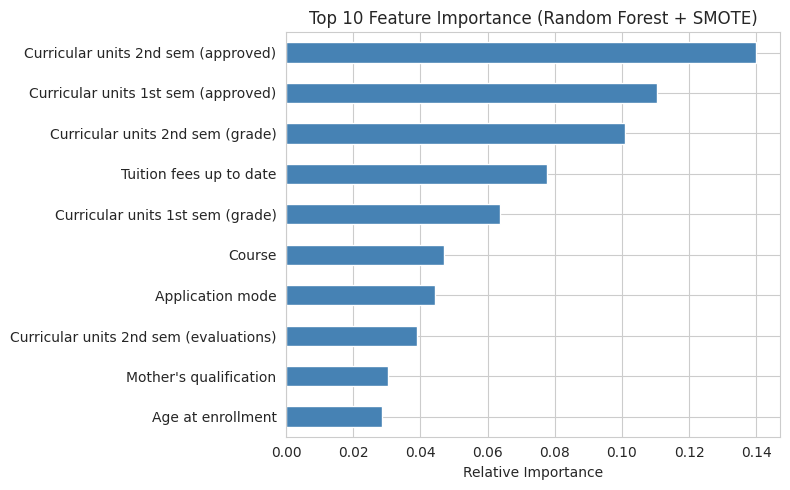

In [ ]:
rf = tuned_models[('SMOTE', 'Random Forest')]
imp = pd.Series(rf.feature_importances_, index=feature_names)

def original_name(col):
    col = col.split('__', 1)[1]            # ตัด prefix num__ / cat__ / bin__
    for c in cat_cols:                     # คอลัมน์ One-Hot มีรูปแบบ "ชื่อเดิม_ค่า"
        if col.startswith(c + '_'):
            return c
    return col

imp_grouped = imp.groupby(original_name).sum().sort_values(ascending=False)
print(imp_grouped.head(10).round(3))
print("รวมทั้งหมด:", imp_grouped.sum().round(3))   # ควรเท่ากับ 1.0

top = imp_grouped.head(10).sort_values()
plt.figure(figsize=(8, 5))
top.plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importance (Random Forest + SMOTE)')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(final_model, X_val_p, y_val,
                            scoring='f1', n_repeats=5, random_state=42, n_jobs=-1)
pi_s = pd.Series(pi.importances_mean, index=feature_names).groupby(original_name).sum()
print(pi_s.sort_values(ascending=False).head(10).round(3))

Curricular units 2nd sem (approved)    0.245
Curricular units 1st sem (approved)    0.083
Tuition fees up to date                0.045
Curricular units 2nd sem (enrolled)    0.043
Curricular units 1st sem (enrolled)    0.024
Course                                 0.022
Curricular units 1st sem (credited)    0.020
Gender                                 0.016
Curricular units 2nd sem (grade)       0.016
Age at enrollment                      0.014
dtype: float64


# 6.5 บันทึกผล

In [ ]:
import joblib
joblib.dump(final_model, '/content/drive/MyDrive/dropout-project/final_model_svm_smote.joblib')
test_results.to_csv('/content/drive/MyDrive/dropout-project/test_results.csv', index=False)
imp_grouped.to_csv('/content/drive/MyDrive/dropout-project/feature_importance.csv')

สรุปขั้นที่ 6

In [ ]:
   from sklearn.metrics import confusion_matrix
   print(confusion_matrix(y_test, tuned_models[('No SMOTE', 'Logistic Regression')].predict(X_test_p)))

[[430  21]
 [ 44 169]]


## สรุปการประเมินบนชุด Test

ประเมินโมเดลบนชุด Test (664 คน เป็นกลุ่ม Dropout 213 คน) เพียงครั้งเดียว หลังเลือกโมเดลจากชุด Validation เรียบร้อยแล้ว ไม่มีการจูนหรือเปลี่ยนโมเดลซ้ำหลังเห็นผล Test

### ผลเปรียบเทียบทั้ง 6 รูปแบบบนชุด Test (เมตริกของกลุ่ม Dropout)

| Data | Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|---|
| No SMOTE | Logistic Regression | 0.902 | 0.889 | 0.793 | **0.839** | 0.943 |
| No SMOTE | Random Forest | 0.878 | 0.863 | 0.737 | 0.795 | 0.935 |
| No SMOTE | SVM | 0.887 | 0.888 | 0.742 | 0.808 | 0.935 |
| SMOTE | Logistic Regression | 0.877 | 0.784 | 0.850 | 0.815 | 0.941 |
| SMOTE | Random Forest | 0.873 | 0.812 | 0.789 | 0.800 | 0.928 |
| SMOTE | SVM (โมเดลหลัก) | 0.890 | 0.810 | **0.859** | 0.834 | 0.938 |

### 1. ผลของโมเดลหลัก (SVM + SMOTE)

| เมตริก | Validation | Test | ผลต่าง |
|---|---|---|---|
| Accuracy | 0.881 | 0.890 | +0.009 |
| Precision | 0.795 | 0.810 | +0.015 |
| Recall | 0.850 | 0.859 | +0.009 |
| F1 | 0.822 | 0.834 | +0.012 |
| ROC-AUC | 0.933 | 0.938 | +0.005 |

ผลบน Test ใกล้เคียงและสูงกว่า Validation เล็กน้อยในทุกเมตริก แสดงว่าโมเดลทำนายข้อมูลใหม่ได้ดีและไม่พบสัญญาณว่าถูกเลือกเกินจริงจากชุด Validation (ความต่างระดับนี้อยู่ในช่วงความคลาดเคลื่อนปกติ)

จาก Classification Report: กลุ่ม Dropout มี Precision = 0.810, Recall = 0.859, F1 = 0.834 (213 คน) และกลุ่ม Not Dropout มี Precision = 0.932, Recall = 0.905, F1 = 0.918 (451 คน) Accuracy รวม = 0.890 และ Macro F1 = 0.876

### 2. Confusion Matrix

| โมเดล | จับ Dropout ได้ (TP) | พลาด Dropout (FN) | เตือนเกิน (FP) | ทายถูกว่าไม่ลาออก (TN) |
|---|---|---|---|---|
| Logistic Regression (SMOTE) | 181 | 32 | 50 | 401 |
| Random Forest (SMOTE) | 168 | 45 | 39 | 412 |
| **SVM (SMOTE, โมเดลหลัก)** | **183** | **30** | 43 | 408 |
| Logistic Regression (ไม่ใช้ SMOTE, ใช้เปรียบเทียบ) | 169 | 44 | 21 | 430 |

SVM + SMOTE จับนักเรียนที่ลาออกจริงได้ 183 จาก 213 คน (พลาด 30 คน) น้อยที่สุดในทุกโมเดลที่เทียบ โดยเตือนเกิน 43 คนจากนักเรียนที่ไม่ลาออก 451 คน ส่วน Logistic Regression แบบไม่ใช้ SMOTE เตือนเกินน้อยที่สุด (21 คน) แต่พลาดนักเรียนเสี่ยงถึง 44 คน เนื่องจากเป้าหมายของโครงงานคือให้ครูเข้าช่วยเหลือนักเรียนเสี่ยงได้ทันเวลา การพลาดนักเรียนเสี่ยง (FN) เสียหายกว่าการเตือนเกิน (FP) จึงให้น้ำหนักกับ Recall เป็นหลัก

### 3. ROC Curve
ทั้ง 3 โมเดลที่ใช้ SMOTE ให้ค่า AUC ใกล้เคียงกัน (Logistic Regression 0.941, SVM 0.938, Random Forest 0.928) และเส้นโค้งอยู่เหนือเส้นสุ่มอย่างชัดเจน แสดงว่าทุกโมเดลแยกกลุ่มลาออกกับไม่ลาออกได้ดี

### 4. ผลของ SMOTE บนชุด Test

| โมเดล | Recall (ไม่ใช้ → ใช้ SMOTE) | Precision | F1 |
|---|---|---|---|
| Logistic Regression | 0.793 → 0.850 (+0.057) | 0.889 → 0.784 (-0.105) | 0.839 → 0.815 (-0.024) |
| Random Forest | 0.737 → 0.789 (+0.052) | 0.863 → 0.812 (-0.051) | 0.795 → 0.800 (+0.005) |
| SVM | 0.742 → 0.859 (+0.117) | 0.888 → 0.810 (-0.078) | 0.808 → 0.834 (+0.026) |

SMOTE เพิ่ม Recall ของกลุ่ม Dropout ในทั้ง 3 โมเดล (+0.05 ถึง +0.12) โดยแลกกับ Precision ที่ลดลง ส่วนผลต่อ F1 ไม่สม่ำเสมอ (SVM ดีขึ้น Random Forest เกือบเท่าเดิม และ Logistic Regression ลดลง) ต่างจากผลบน Validation ที่ F1 ดีขึ้นในทุกโมเดล จึงสรุปได้ว่าประโยชน์ที่ชัดเจนและสม่ำเสมอของ SMOTE ในงานนี้คือการจับนักเรียนเสี่ยงได้มากขึ้น มากกว่าการทำให้ F1 ดีขึ้นเสมอไป

### 5. การเลือกโมเดลสุดท้าย
บน Test โมเดล Logistic Regression แบบไม่ใช้ SMOTE มี F1 สูงสุด (0.839) สูงกว่า SVM + SMOTE (0.834) เพียง 0.005 ซึ่งเป็นความต่างที่เล็กมากเมื่อเทียบกับขนาดกลุ่ม Dropout ในชุด Test (213 คน) เมื่อเทียบ Confusion Matrix โดยตรง SVM + SMOTE จับนักเรียนที่ลาออกจริงได้เพิ่มอีก 14 คน (พลาด 30 คน เทียบกับ 44 คน) โดยแลกกับการเตือนเกินเพิ่มอีก 22 คน (43 คน เทียบกับ 21 คน) เมื่อพิจารณาว่าการพลาดนักเรียนเสี่ยงเสียหายกว่าการเตือนเกิน จึงคงเลือก **SVM + SMOTE** เป็นโมเดลหลัก ตามที่เลือกไว้จากชุด Validation และตรงกับเป้าหมายด้าน Recall ทั้งนี้ Logistic Regression เป็นทางเลือกที่ดีเช่นกัน โดยเฉพาะหากโรงเรียนมีทรัพยากรช่วยเหลือจำกัดและต้องการลดการเตือนเกิน เพราะตีความค่าน้ำหนักได้ง่ายกว่าด้วย

### 6. Feature Importance

**Random Forest + SMOTE (Top 5):** Curricular units 2nd sem (approved) 0.140, Curricular units 1st sem (approved) 0.111, Curricular units 2nd sem (grade) 0.101, Tuition fees up to date 0.078 และ Curricular units 1st sem (grade) 0.064

**Permutation Importance ของ SVM (วัดบน Validation, ค่าคือการลดลงของ F1 เมื่อสลับค่าฟีเจอร์ Top 5):** Curricular units 2nd sem (approved) 0.245, Curricular units 1st sem (approved) 0.083, Tuition fees up to date 0.045, Curricular units 2nd sem (enrolled) 0.043 และ Curricular units 1st sem (enrolled) 0.024

**ข้อสังเกต**
- ทั้งสองวิธีให้ผลสอดคล้องกัน: จำนวนวิชาที่ผ่านในภาคเรียนที่ 2 และ 1 เป็นสองอันดับแรก และสถานะการชำระค่าเทอมอยู่อันดับต้นๆ ตรงกับผล correlation ในขั้น EDA ที่ฟีเจอร์ผลการเรียนและค่าเทอมสัมพันธ์กับการลาออกสูงสุด
- ฟีเจอร์ `Course`, `Application mode` และ `Mother's qualification` ปรากฏใน Top 10 ของ Random Forest แต่ใน Permutation Importance ของ SVM `Course` มีค่าเพียง 0.022 (และสองฟีเจอร์หลังไม่ติด Top 10) ซึ่งสอดคล้องกับข้อจำกัดที่ว่า Feature Importance ของ Random Forest มักให้ค่าสูงกับฟีเจอร์หมวดหมู่ที่มีหลายค่า จึงควรตีความฟีเจอร์เหล่านี้อย่างระมัดระวัง
- ฟีเจอร์ด้านเศรษฐกิจมหภาค (Unemployment rate, Inflation rate, GDP) ไม่ติด Top 10 ในทั้งสองวิธี

### 7. ข้อจำกัด
- ฟีเจอร์ที่สำคัญที่สุด (จำนวนวิชาที่ผ่านในภาคเรียนที่ 2) เป็นข้อมูลที่เกิดขึ้นช้า นักเรียนบางคนอาจเริ่มหลุดจากระบบแล้วก่อนถึงตอนนั้น โมเดลนี้จึงยังไม่ใช่การเตือนล่วงหน้าที่เร็วที่สุด การทดลองตัดฟีเจอร์ภาคเรียนที่ 2 ออกเพื่อดูว่าโมเดลเตือนจากข้อมูลภาคแรกได้แค่ไหน เป็นแนวทางต่อยอดที่น่าสนใจ
- ข้อมูลมาจากสถาบันเดียวในช่วงเวลาหนึ่ง และไม่มีฟีเจอร์การเข้าเรียน การส่งงาน และวินัย ตามที่เสนอไว้ในข้อเสนอโครงงานเดิม จึงอาจใช้กับโรงเรียนอื่นได้ไม่เท่ากัน
- ผลแสดงความสัมพันธ์เชิงพยากรณ์ ไม่ใช่ความเป็นเหตุเป็นผล และชุด Test มีกลุ่ม Dropout 213 คน ความต่างของเมตริกในระดับ 0.01 จึงไม่ควรตีความเกินจริง

# 7. Risk Level และบันทึกโมเดล

## 7.1 ฝึก SVM ใหม่ให้ได้คะแนนความเสี่ยง (probability=True)

In [ ]:
import json, joblib
from sklearn.svm import SVC

best = tuned_models[('SMOTE', 'SVM')]          # ดึงค่าที่จูนไว้ ไม่ต้องพิมพ์เอง
svm_prob = SVC(C=best.C, gamma=best.gamma, kernel=best.kernel,
               probability=True, random_state=42)
svm_prob.fit(X_train_sm, y_train_sm)

print("params:", svm_prob.get_params()['C'], svm_prob.get_params()['gamma'])
print(pd.Series(evaluate(svm_prob, X_test_p, y_test)).round(3))

params: 1 0.01
Accuracy     0.890
Precision    0.810
Recall       0.859
F1           0.834
ROC-AUC      0.938
dtype: float64


## 7.2 กำหนดเกณฑ์ ต่ำ/กลาง/สูง จากชุด Validation

t_low = 0.22 | t_high = 0.68


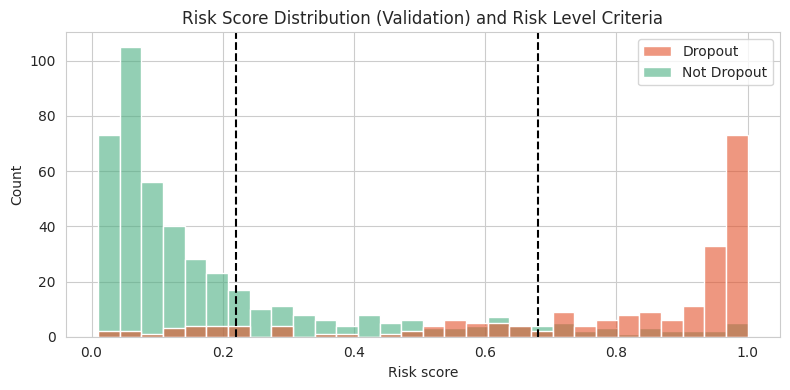

In [ ]:
TARGET_LOW_RATE  = 0.05   # Low: มี Dropout จริงไม่เกิน 5%
TARGET_HIGH_PREC = 0.85   # High: มี Dropout จริงอย่างน้อย 85%
MIN_GROUP        = 30     # ขนาดกลุ่มขั้นต่ำ กันเกณฑ์ที่อิงคนไม่กี่คน

val_score = svm_prob.predict_proba(X_val_p)[:, 1]
yv = y_val.to_numpy()
grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

# t_low: ขยายเกณฑ์ขึ้นเรื่อยๆ จนอัตรา Dropout ในกลุ่ม Low เกินเป้า
t_low = None
for t in grid:
    m = val_score < t
    if m.sum() < MIN_GROUP:
        continue
    if yv[m].mean() <= TARGET_LOW_RATE:
        t_low = t
    else:
        break

# t_high: หาค่าต่ำสุดที่กลุ่ม High มี Dropout จริงตามเป้า
t_high = None
for t in grid:
    m = val_score >= t
    if m.sum() >= MIN_GROUP and yv[m].mean() >= TARGET_HIGH_PREC:
        t_high = t
        break

if t_low is None or t_high is None or t_low >= t_high:
    print("เกณฑ์อัตโนมัติใช้ไม่ได้ ใช้ค่าเริ่มต้น 0.30 / 0.70 แทน")
    t_low, t_high = 0.30, 0.70

print(f"t_low = {t_low} | t_high = {t_high}")

def to_band(score):
    return pd.cut(score, bins=[-0.001, t_low, t_high, 1.001],
                  labels=['Low', 'Medium', 'High'], right=False)

# กราฟการกระจายคะแนน แยกตามผลจริง
plt.figure(figsize=(8, 4))
sns.histplot(x=val_score, hue=np.where(yv == 1, 'Dropout', 'Not Dropout'),
             bins=30, alpha=0.6,
             palette={'Not Dropout': '#4CAF82', 'Dropout': '#E3522B'})
plt.axvline(t_low, color='k', ls='--')
plt.axvline(t_high, color='k', ls='--')
plt.title('Risk Score Distribution (Validation) and Risk Level Criteria')
plt.xlabel('Risk score')
plt.tight_layout()
plt.show()

## 7.3 ตรวจเกณฑ์บนชุด Validation และ Test

--- Validation (ใช้กำหนดเกณฑ์) ---


,Students,Dropouts,DropoutRate,ShareOfAllDropouts
band,,,,
Low,349,17,0.049,0.079
Medium,126,36,0.286,0.168
High,189,161,0.852,0.752


--- Test (ตรวจผลจริง) ---


,Students,Dropouts,DropoutRate,ShareOfAllDropouts
band,,,,
Low,340,14,0.041,0.066
Medium,129,30,0.233,0.141
High,195,169,0.867,0.793


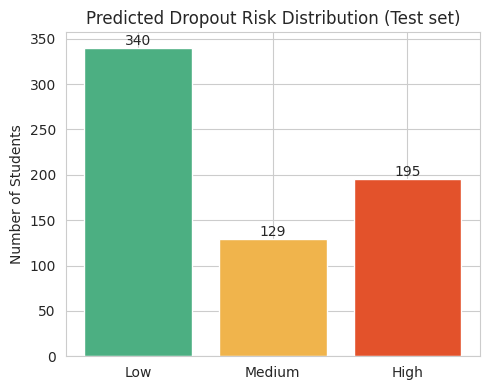

In [ ]:
def summarize(score, y, name):
    y = np.asarray(y)
    tab = (pd.DataFrame({'band': to_band(score), 'dropout': y})
             .groupby('band', observed=False)['dropout']
             .agg(Students='count', Dropouts='sum', DropoutRate='mean'))
    tab['ShareOfAllDropouts'] = tab['Dropouts'] / tab['Dropouts'].sum()
    print(f"--- {name} ---")
    return tab.round(3)

test_score = svm_prob.predict_proba(X_test_p)[:, 1]

display(summarize(val_score,  y_val,  'Validation (ใช้กำหนดเกณฑ์)'))
display(summarize(test_score, y_test, 'Test (ตรวจผลจริง)'))

# กราฟจำนวนนักเรียนตามระดับความเสี่ยง (ใช้แทน Mock ในข้อเสนอรูปที่ 1)
counts = to_band(test_score).value_counts().reindex(['Low', 'Medium', 'High'])
plt.figure(figsize=(5, 4))
bars = plt.bar(counts.index, counts.values, color=['#4CAF82', '#F0B44C', '#E3522B'])
plt.bar_label(bars)
plt.title('Predicted Dropout Risk Distribution (Test set)')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

## 7.4 ตารางพยากรณ์รายบุคคล

In [ ]:
cols = ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
        'Curricular units 2nd sem (approved)', 'Tuition fees up to date']

result = X_test[cols].copy()
result.insert(0, 'Student ID', ['ST-' + str(i).zfill(4) for i in result.index])
result['Risk score'] = test_score.round(3)
result['Risk level'] = to_band(test_score).astype(str)
result['Actual dropout'] = y_test.to_numpy()
result = result.sort_values('Risk score', ascending=False).reset_index(drop=True)

result.head(10)

,Student ID,Curricular units 1st sem (grade),Curricular units 2nd sem (grade),Curricular units 2nd sem (approved),Tuition fees up to date,Risk score,Risk level,Actual dropout
0,ST-2781,10.333333,11.0,1,0,1.0,High,1
1,ST-2448,0.000000,0.0,0,0,1.0,High,1
2,ST-4283,11.000000,0.0,0,0,1.0,High,1
3,ST-3854,11.000000,0.0,0,0,1.0,High,1
4,ST-1222,0.000000,0.0,0,0,1.0,High,1
5,ST-4404,11.000000,10.5,2,0,1.0,High,1
6,ST-1549,0.000000,0.0,0,0,1.0,High,1
7,ST-2788,0.000000,0.0,0,0,1.0,High,1
8,ST-3721,10.000000,0.0,0,0,1.0,High,1
9,ST-1850,0.000000,0.0,0,0,1.0,High,1


## 7.5 บันทึกไฟล์สำหรับ Dashboard

In [ ]:
out = '/content/drive/MyDrive/dropout-project/'

joblib.dump(svm_prob, out + 'final_model_svm_prob.joblib')

config = {
    't_low': float(t_low),
    't_high': float(t_high),
    'feature_columns': list(X.columns),
    'cat_cols': cat_cols, 'bin_cols': bin_cols, 'num_cols': num_cols,
}
with open(out + 'config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

result.to_csv(out + 'test_risk_table.csv', index=False)
X_test.assign(Dropout=y_test.to_numpy()).to_csv(out + 'test_raw.csv')   # ข้อมูลดิบชุด Test ไว้ให้ Dashboard ลองทำนายใหม่
print("saved")

saved


## สรุปการกำหนดระดับความเสี่ยง (Low / Medium / High)

### 1. คะแนนความเสี่ยง
ฝึก SVM (C = 1, gamma = 0.01) บนข้อมูล train ที่ผ่าน SMOTE ซ้ำด้วย `probability=True` เพื่อให้ได้คะแนนความเสี่ยงช่วง 0-1 ผลทำนายบนชุด Test เท่าเดิมทุกเมตริก (Accuracy 0.890, Precision 0.810, Recall 0.859, F1 0.834, ROC-AUC 0.938) แสดงว่าการเปลี่ยนมาใช้โมเดลที่ให้คะแนนไม่กระทบประสิทธิภาพ

คะแนนนี้ใช้จัดอันดับความเสี่ยง ไม่ใช่ความน่าจะเป็นจริงของการลาออก เพราะโมเดลถูกฝึกบนข้อมูลที่ปรับสมดุลด้วย SMOTE จึงอธิบายความหมายของแต่ละระดับด้วยอัตราลาออกจริงในตารางด้านล่างแทน

### 2. การกำหนดเกณฑ์
กำหนดเกณฑ์จากชุด Validation ด้วยเงื่อนไข 2 ข้อ คือ กลุ่ม Low ต้องมีนักเรียนที่ลาออกจริงไม่เกิน 5% และกลุ่ม High ต้องมีนักเรียนที่ลาออกจริงอย่างน้อย 85% ได้เกณฑ์ดังนี้

- **Low:** คะแนน < 0.22
- **Medium:** 0.22 ≤ คะแนน < 0.68
- **High:** คะแนน ≥ 0.68

จากฮิสโตแกรมของคะแนนบน Validation นักเรียนที่ไม่ลาออกกระจุกตัวที่คะแนนต่ำ (ต่ำกว่าประมาณ 0.2) ขณะที่นักเรียนที่ลาออกกระจุกตัวที่คะแนนใกล้ 1.0 ส่วนช่วงกลางมีทั้งสองกลุ่มปะปนกัน จึงเป็นที่มาของกลุ่ม Medium ซึ่งเป็นกลุ่มที่ควรติดตาม

### 3. ผลตามระดับความเสี่ยง

| ระดับ | Validation: นักเรียน | Validation: อัตราลาออกจริง | Test: นักเรียน | Test: ลาออกจริง (คน) | Test: อัตราลาออกจริง | Test: สัดส่วนของผู้ลาออกทั้งหมด |
|---|---|---|---|---|---|---|
| Low | 349 | 4.9% (17 คน) | 340 | 14 | 4.1% | 6.6% |
| Medium | 126 | 28.6% (36 คน) | 129 | 30 | 23.3% | 14.1% |
| High | 189 | 85.2% (161 คน) | 195 | 169 | 86.7% | 79.3% |

### 4. ข้อสังเกต

- **อัตราลาออกจริงเพิ่มขึ้นตามระดับความเสี่ยงอย่างชัดเจน** ทั้งบน Validation และ Test (Test: 4.1% → 23.3% → 86.7%) และเกณฑ์ที่กำหนดจาก Validation ให้ผลสอดคล้องกันบนชุด Test (Low 4.1% ไม่เกินเป้า 5% และ High 86.7% สูงกว่าเป้า 85%) แสดงว่าเกณฑ์ใช้ได้กับข้อมูลที่ไม่เคยเห็น
- **ประโยชน์เชิงปฏิบัติ:** กลุ่ม High มี 195 คน (29.4% ของนักเรียน) ครอบคลุมผู้ลาออกจริง 169 คน (79.3% ของผู้ลาออกทั้งหมด) และหากรวมกลุ่ม Medium ด้วย (324 คน หรือ 48.8% ของนักเรียน) จะครอบคลุมผู้ลาออกถึง 199 จาก 213 คน (93.4%) ขณะที่กลุ่ม Low 340 คน (51.2%) มีผู้ลาออกเพียง 14 คน ครูจึงจัดลำดับการดูแลได้โดยไม่ต้องติดตามนักเรียนทั้งหมด
- **การเตือนเกินในกลุ่ม High** มี 26 คน (195 - 169) หรือประมาณ 13% ของกลุ่ม
- **นักเรียนที่ระบบพลาด:** มีผู้ลาออกจริง 14 คน (6.6%) ที่ถูกจัดอยู่ในกลุ่ม Low จึงไม่ควรตีความว่ากลุ่ม Low ปลอดภัยทั้งหมด
- **ตัวอย่างรายบุคคล:** นักเรียน 10 อันดับแรกของชุด Test ทุกคนได้คะแนน 1.000 อยู่ในระดับ High และลาออกจริงทั้งหมด ทั้ง 10 คนมีสถานะค่าเทอมไม่เป็นปัจจุบัน และจำนวนวิชาที่ผ่านในภาคเรียนที่ 2 ไม่เกิน 2 วิชา (8 ใน 10 คนเป็น 0) ซึ่งสอดคล้องกับฟีเจอร์ที่สำคัญที่สุดจากขั้น Feature Importance

### 5. ข้อจำกัด
- คะแนนของนักเรียนจำนวนมากกระจุกตัวใกล้ 1.0 ทำให้จัดลำดับความเสี่ยงภายในกลุ่ม High ได้ไม่ละเอียด (หลายคนได้คะแนนเท่ากัน)
- เกณฑ์ 5% และ 85% เป็นค่าที่ตั้งเพื่อทดลอง โรงเรียนจริงควรปรับตามทรัพยากรช่วยเหลือที่มี (เช่น ถ้าครูดูแลได้น้อย ให้เพิ่มความเข้มของเกณฑ์ High)
- โมเดลอาศัยข้อมูลภาคเรียนที่ 2 เป็นสำคัญ นักเรียนบางคนที่ถูกจัดเป็น High อาจเริ่มหลุดจากระบบไปแล้ว จึงยังไม่ใช่การเตือนล่วงหน้าที่เร็วที่สุด
- รหัสนักเรียน (ST-xxxx) สร้างจากลำดับแถวของข้อมูลเพื่อใช้สาธิต เพราะชุดข้อมูลสาธารณะไม่มีรหัสจริง และชุดข้อมูลไม่มีฟีเจอร์การเข้าเรียนตามที่เสนอไว้เดิม
- ผลเป็นการพยากรณ์เชิงสถิติ ไม่ใช่ความเป็นเหตุเป็นผล และต้องใช้ประกอบการพิจารณาของครูเท่านั้น ไม่ควรใช้ตัดสินนักเรียนโดยอัตโนมัติ